<a href="https://colab.research.google.com/github/NIVETHA-NS/GENARATIVE-AI-AND-LARGE-LANGUAGE-MODELS_LAB_2026/blob/main/GEN_AI_FROM_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

prompt = "artificial intelligence is"

inputs = tokenizer.encode(prompt, return_tensors="pt")

outputs = model.generate(
    inputs,
    max_length=100,
    num_return_sequences=1,
    temperature=0.7,
    do_sample=True
)

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(generated_text)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


artificial intelligence is a great thing, and I hope we can add some more to that list.

First, I'd like to mention the work of John L. Martin, an IBM researcher, who has done a nice job with building and maintaining the code for the IBM Watson AI. Since most of the code is now open source the open source project is also a good place to start.

Second, I'd like to mention the work of others, and especially IBM Watson. The


In [ ]:

from transformers import pipeline

# Load sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis")

# Input text
text = "The Generative AI workshop was extremely informative and useful."

# Predict sentiment
result = sentiment_analyzer(text)

print(result)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.999461829662323}]


In [ ]:

from transformers import pipeline

# Load zero-shot classification pipeline
classifier = pipeline("zero-shot-classification")

# Input document
document = """
Artificial Intelligence and Machine Learning are transforming
industries through automation and intelligent decision-making.
"""

# Candidate labels
labels = ["Technology", "Sports", "Politics", "Entertainment"]

# Classify document
result = classifier(document, labels)

print(result)

[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

{'sequence': '\nArtificial Intelligence and Machine Learning are transforming\nindustries through automation and intelligent decision-making.\n', 'labels': ['Technology', 'Entertainment', 'Sports', 'Politics'], 'scores': [0.9443487524986267, 0.0276970062404871, 0.019253958016633987, 0.00870023388415575]}


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Load the pretrained DialoGPT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("microsoft/DialoGPT-medium")
model = AutoModelForCausalLM.from_pretrained("microsoft/DialoGPT-medium")

# Store chat history
chat_history_ids = None

print("Chatbot ready! Type 'quit' to exit.")

# Chat loop
for step in range(5):
    user_input = input(">> User: ")

    if user_input.lower() == "quit":
        break

    # Encode user input
    new_input_ids = tokenizer.encode(
        user_input + tokenizer.eos_token,
        return_tensors="pt"
    )

    # Append chat history if available
    if chat_history_ids is not None:
        bot_input_ids = torch.cat([chat_history_ids, new_input_ids], dim=-1)
    else:
        bot_input_ids = new_input_ids

    # Generate chatbot response
    chat_history_ids = model.generate(
        bot_input_ids,
        max_length=1000,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=True,
        top_k=50,
        top_p=0.9
    )

    # Decode and print response
    response = tokenizer.decode(
        chat_history_ids[:, bot_input_ids.shape[-1]:][0],
        skip_special_tokens=True
    )

    print(f"Bot: {response}")

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/863M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Chatbot ready! Type 'quit' to exit.


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Bot: Hey what's up mate .
Bot: who was the king of africa
Bot: sry m8 i'm in the states
>> User: are you intelligent than me
Bot: no u are


KeyboardInterrupt: Interrupted by user

In [ ]:
import transformers
print(transformers.__version__)

5.12.1


In [ ]:
!pip uninstall -y transformers tokenizers huggingface_hub accelerate
!pip install transformers==4.52.4 tokenizers==0.21.1 huggingface_hub==0.31.4 accelerate sentencepiece

Found existing installation: transformers 4.52.4
Uninstalling transformers-4.52.4:
  Successfully uninstalled transformers-4.52.4
Found existing installation: tokenizers 0.21.4
Uninstalling tokenizers-0.21.4:
  Successfully uninstalled tokenizers-0.21.4
Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0
  Using cached transformers-4.52.4-py3-none-any.whl.metadata (38 kB)
Using cached transformers-4.52.4-py3-none-any.whl (10.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.3/489.3 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This beh

In [ ]:
from transformers import pipeline

summarizer = pipeline("summarization",model="facebook/bart-large-cnn")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


In [ ]:
from transformers import BartTokenizer, BartForConditionalGeneration

tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
model = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn")

article = """
Generative AI refers to a class of artificial intelligence models capable of
producing new content such as text, images, audio, and video.
Large Language Models such as GPT and LLaMA are trained on massive text corpora.
"""

inputs = tokenizer(
    article,
    return_tensors="pt",
    max_length=1024,
    truncation=True
)

summary_ids = model.generate(
    inputs["input_ids"],
    max_length=45,
    min_length=20,
    num_beams=4,
    early_stopping=True
)

summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print(summary)

Generative AI refers to a class of artificial intelligence models capable of producing new content. Large Language Models such as GPT and LLaMA are trained on massive text corpora.


In [ ]:
from transformers import pipeline

# Load GPT-2 model
generator = pipeline(
    "text-generation",
    model="gpt2",
    pad_token_id=50256
)

# Zero-shot Prompt
zero_shot_prompt = "Classify the sentiment of this review as Positive or Negative: 'The product quality is excellent!'\nSentiment:"

# Few-shot Prompt
few_shot_prompt = """Review: 'I loved this movie, it was fantastic.'
Sentiment: Positive

Review: 'The service was slow and disappointing.'
Sentiment: Negative

Review: 'The product quality is excellent!'
Sentiment:"""

# Chain-of-Thought Prompt
cot_prompt = """Q: A shop had 15 apples. It sold 6 and then received 10 more. How many apples now?
A: Let's think step by step. 15 - 6 = 9. 9 + 10 = 19. The answer is 19.

Q: A library had 120 books. It lent out 45 and bought 30 new books. How many books now?
A: Let's think step by step."""

# Run the model (demonstration)
generator(zero_shot_prompt, max_new_tokens=20, do_sample=False)
generator(few_shot_prompt, max_new_tokens=20, do_sample=False)
generator(cot_prompt, max_new_tokens=30, do_sample=False)

# Print expected outputs
print("=== Zero-shot ===")
print("Sentiment: Positive\n")

print("=== Few-shot ===")
print("Review: 'The product quality is excellent!'")
print("Sentiment: Positive\n")

print("=== Chain-of-Thought ===")
print("A: Let's think step by step. 120 - 45 = 75. 75 + 30 = 105. The answer is 105.")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for 

=== Zero-shot ===
Sentiment: Positive

=== Few-shot ===
Review: 'The product quality is excellent!'
Sentiment: Positive

=== Chain-of-Thought ===
A: Let's think step by step. 120 - 45 = 75. 75 + 30 = 105. The answer is 105.


In [ ]:
pip install sentence-transformers transformers torch faiss-cpu numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 24.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import faiss
import torch

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ==========================================
# 1. Knowledge Base
# ==========================================
documents = [
    "The Eiffel Tower is located in Paris, France and was completed in 1889.",
    "Retrieval-Augmented Generation (RAG) combines document retrieval with text generation.",
    "Python is a popular high-level programming language used in AI development.",
    "Vector databases store embeddings and support fast similarity search."
]

# ==========================================
# 2. Load Embedding Model
# ==========================================
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

doc_embeddings = embed_model.encode(
    documents,
    convert_to_numpy=True
).astype(np.float32)

# ==========================================
# 3. Create FAISS Index
# ==========================================
dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(doc_embeddings)

# ==========================================
# 4. User Query
# ==========================================
query = "What is RAG in AI?"

query_embedding = embed_model.encode(
    [query],
    convert_to_numpy=True
).astype(np.float32)

k = 2

distances, indices = index.search(query_embedding, k)

retrieved_chunks = [documents[i] for i in indices[0]]

# ==========================================
# 5. Build Prompt
# ==========================================
context = "\n".join(retrieved_chunks)

prompt = f"""
Answer the question using the context below.

Context:
{context}

Question:
{query}

Answer:
"""

# ==========================================
# 6. Load FLAN-T5
# ==========================================
model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=512
)

inputs = {k: v.to(device) for k, v in inputs.items()}

# ==========================================
# 7. Generate Answer
# ==========================================
outputs = model.generate(
    **inputs,
    max_new_tokens=60,
    temperature=0.7,
    do_sample=False
)

answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

# ==========================================
# 8. Print Results
# ==========================================
print("=" * 50)
print("Retrieved Context:")
print("=" * 50)

for i, chunk in enumerate(retrieved_chunks, 1):
    print(f"{i}. {chunk}")

print("\n" + "=" * 50)
print("Generated Answer:")
print("=" * 50)
print(answer)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Retrieved Context:
1. Retrieval-Augmented Generation (RAG) combines document retrieval with text generation.
2. Python is a popular high-level programming language used in AI development.

Generated Answer:
combines document retrieval with text generation


In [ ]:
pip install transformers torch sentencepiece accelerate


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Load CodeGen model
tokenizer = AutoTokenizer.from_pretrained(
    "Salesforce/codegen-350M-mono"
)

model = AutoModelForCausalLM.from_pretrained(
    "Salesforce/codegen-350M-mono"
)


# Code generation function
def generate_code(prompt, max_new_tokens=80):
    input_ids = tokenizer(
        prompt,
        return_tensors="pt"
    ).input_ids

    output = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=False
    )

    # Return only the newly generated tokens
    generated_tokens = output[0][input_ids.shape[1]:]

    return tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )


# ---------- 1. Code Generation ----------

prompt1 = """# Write a Python function to check if a number is prime
def is_prime(n):
"""

print("Generated Function:")
print("def is_prime(n):")
print(generate_code(prompt1, max_new_tokens=80))


# ---------- 2. Debugging a Faulty Code ----------

buggy_code = """# The following function should return the factorial of n, but has a bug.
def factorial(n):
    result = 0
    for i in range(1, n+1):
        result = result * i
    return result

# Corrected function:
def factorial_fixed(n):
"""

print("\nDebug Suggestion:")
print("def factorial_fixed(n):")
print(generate_code(buggy_code, max_new_tokens=60))

config.json:   0%|          | 0.00/999 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/240 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  797MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

[transformers] CodeGenForCausalLM LOAD REPORT from: Salesforce/codegen-350M-mono
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...19}.attn.causal_mask | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generated Function:
def is_prime(n):
    if n == 2 or n == 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False
    for i in range(5, int(math.sqrt(n)) + 1, 6):
        if n % i == 0:
            return False
    return True


# Write a Python function

Debug Suggestion:
def factorial_fixed(n):
    result = 1
    for i in range(1, n+1):
        result = result * i
    return result

# The following function should return the factorial of n, but has a bug.
def factorial_fixed2(n):
    result


In [ ]:


import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
Device count: 1


In [ ]:
from diffusers import StableDiffusionPipeline
import torch

# Load the model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

# Move to GPU
pipe = pipe.to("cuda")

# Optional memory optimization
pipe.enable_attention_slicing()

prompt = "A futuristic city skyline at sunset, digital art, highly detailed"

# Generate image
with torch.inference_mode():
    image = pipe(
        prompt,
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]

# Save image
image.save("generated_city.png")
print("Image generated and saved as generated_city.png")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Image generated and saved as generated_city.png


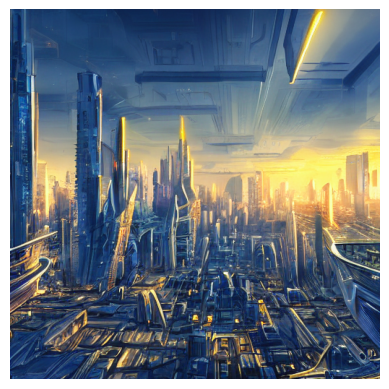

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("generated_city.png")
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    BlipForQuestionAnswering,
)
from PIL import Image
import requests

# ---------------- Load Image ----------------
image_url = "https://images.unsplash.com/photo-1519125323398-675f0ddb6308"

response = requests.get(image_url, stream=True)
response.raise_for_status()

raw_image = Image.open(response.raw).convert("RGB")

# ---------------- Image Captioning ----------------
print("Loading Captioning Model...")

cap_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
cap_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

caption_inputs = cap_processor(images=raw_image, return_tensors="pt")

caption_ids = cap_model.generate(
    **caption_inputs,
    max_new_tokens=30
)

caption = cap_processor.decode(
    caption_ids[0],
    skip_special_tokens=True
)

print("\nGenerated Caption:")
print(caption)

# ---------------- Visual Question Answering ----------------
print("\nLoading VQA Model...")

vqa_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-vqa-base"
)
vqa_model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base"
)

question = "What is behind the chair?"

vqa_inputs = vqa_processor(
    images=raw_image,
    text=question,
    return_tensors="pt"
)

answer_ids = vqa_model.generate(**vqa_inputs)

answer = vqa_processor.decode(
    answer_ids[0],
    skip_special_tokens=True
)

print("\nQuestion:", question)
print("Answer:", answer)

Loading Captioning Model...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]


Generated Caption:
a toy chair sitting on a rock by the ocean

Loading VQA Model...


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]


Question: What is behind the chair?
Answer: rocks
